# 미션 소개
이번 미션에서는 지금까지 배운 지도 학습 알고리즘을 총동원해서, 전 세계에서 가장 유명한 머신러닝 입문 대회인 캐글 타이타닉 대회에 직접 참가합니다.

1912년, 타이타닉호는 첫 항해 중 빙산과 충돌해 침몰했고 승객 2,224명 중 1,502명이 사망했습니다. 생존에는 운도 작용했지만, 데이터를 보면 어떤 집단이 더 많이 살아남았는지 뚜렷한 패턴이 있습니다. 여러분은 승객 정보를 바탕으로 누가 생존했는지(Survived) 예측하는 이진 분류 모델을 만들어, 실제 캐글 리더보드에 제출해 보세요.

이 미션은 데이터를 분석하고 인사이트를 뽑아내는 것보다, 전처리부터 모델 튜닝까지 지도 학습 파이프라인을 얼마나 잘 구축하는지를 확인하는 데 목적이 있습니다. 로지스틱 회귀, 결정트리, 앙상블 기법을 모두 실험해 보고, 어떤 모델과 설정이 가장 좋은 성능을 내는지 직접 확인해 보세요.

In [ ]:
import kagglehub

#Download lastest version
path = kagglehub.competition_download('titanic')

print("Path to competition file:", path)


c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 34.1k/34.1k [00:00<00:00, 14.3MB/s]

Extracting files...
Path to competition file: C:\Users\dsbang\.cache\kagglehub\competitions\titanic


In [2]:
PATH = 'C:/Users/dsbang/.cache/kagglehub/competitions/titanic' 

import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.read_csv(PATH +'/train.csv')
test_df = pd.read_csv(PATH + '/test.csv')

train_df.head() 
#target_df = train_df['Survived']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 데이터 소개
타이타닉 승객 891명의 정보가 담긴 train 데이터와, 생존 여부를 예측해야 하는 승객 418명의 test 데이터가 제공됩니다.

## 데이터 정의서
|컬럼명 |데이터 타입 | 설명 |
|:-------|:---------:|:---------------|
|PassengerId | int | 승객 고유번호, 제출 파일의 키로 사용됩니다.|
|Survived | int | 타깃 변수. 생존 여부(0:사망, 1:생존). train 데이터에만 존재하고, 예측 대상입니다.|
|Pclass | int | 티켓 등급(1: 1등석, 2: 2등석, 3:3등석). 사회경제적 지위를 대신 보여주는 변수입니다. |
|Name |	object(str) |	승객 이름. Mr, Mrs, Miss, Master 같은 호칭이 포함되어 있습니다.|
|Sex | object	| 성별. |
|Age	|float	|나이. 1살 미만은 소수점으로 표기됩니다.
|SibSp	|int	|함께 탑승한 형제자매와 배우자 수. # of siblings / spouses aboard the Titanic
|Parch	|int	|함께 탑승한 부모와 자녀 수. # of parents / children aboard the Titanic
|Ticket	|object	|티켓 번호.
|Fare	|float	|운임.
|Cabin	|object	|객실 번호.
|Embarked	|object	|탑승 항구(C: Cherbourg, Q: Queenstown, S: Southampton).

In [3]:
display(train_df.head() )
display(test_df.head()) 

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 1. 데이터 전처리
중복행, 컬럼별 결측치 비율을 확인 

In [4]:
feature_cols = ['PassengerId','Pclass','Sex','Age','SibSp','Parch','Ticket','Fare','Cabin','Embarked']
target_col = ['Survived']
df = train_df
print("=" * 60)
print("1. 데이터 기본 구조 및 결측치 요약")
print("=" * 60)
print(f"- 데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print(f"- 중복 행 수: {df.duplicated().sum()}개")
print(f"- 결측 총갯수:  {df.isnull().sum().sum()}개  ")
print(f"- 결측 값있는 행수:  { df.isnull().any(axis=1).sum() }행  ")
print(f"- 결측 행의 전체 비율:  {( df.isnull().any(axis=1).sum() / len(df)).round(4):.1%}  ")

print(f"- 입력 Feasture의 결측 갯수: {df[feature_cols].isnull().sum().sum()}개")
print(f"- 입력 Feasture의 결측 행수: {df[feature_cols].isnull().any(axis=1).sum()}행")    
print(f"- 입력 Feasture의 결측 행의 전체중 비율: {df[feature_cols].isnull().any(axis=1).sum() / len(df):.1%}")  
# 1. 결측값이 있는 컬럼 확인
print("== 컬럼별 결측 수량 확인: ")
display(pd.DataFrame(df.isnull().sum(), columns=['결측수량']))

# 2. 결측값이 있는 각 컬럼별 정보 출력
null_cols = df.isnull().sum()
missing_val_cols = null_cols[null_cols > 0].index

print("=== 결측값이 있는 컬럼별 상세 정보 ===\n")
for col in missing_val_cols:
    print(f" 컬럼명: {col}")
    print(f" 총행수: {len(df[col])}")
    print(f" 결측값 개수: {null_cols[col]}개")
    print(f" 결측값 비율: {null_cols[col]/len(df[col]):.2%}")
    print(f" 최빈값 : { df[col].mode()[0] }")

    if df[col].dtype != 'str':
        print(f" Min값: {df[col].min(numeric_only=True):.2f}")
        print(f" Max값: {df[col].max(numeric_only=True):.2f}")
        print(f" Mean값: {df[col].mean(numeric_only=True):.2f}")
        print(f" Median값: {df[col].median(numeric_only=True):.2f}")    
        print(f" Std값: {df[col].std():.2f}")   


    # dropna=True 옵션으로 결측치를 제외한 유니크 값을 가져옵니다.
    unique_values = df[col].dropna().unique()
    unique_count = df[col].dropna().nunique()

    print(f" 고유값 개수 (결측치 제외): {unique_count}개")
    print(f" 고유값 종류: {unique_values}")
    print(f" 값별 수량: {df[col].value_counts()}")
    print("-" * 40)
    print()

1. 데이터 기본 구조 및 결측치 요약
- 데이터 크기: 891행, 12열
- 중복 행 수: 0개
- 결측 총갯수:  866개  
- 결측 값있는 행수:  708행  
- 결측 행의 전체 비율:  79.5%  
- 입력 Feasture의 결측 갯수: 866개
- 입력 Feasture의 결측 행수: 708행
- 입력 Feasture의 결측 행의 전체중 비율: 79.5%
== 컬럼별 결측 수량 확인: 


,결측수량
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


=== 결측값이 있는 컬럼별 상세 정보 ===

 컬럼명: Age
 총행수: 891
 결측값 개수: 177개
 결측값 비율: 19.87%
 최빈값 : 24.0
 Min값: 0.42
 Max값: 80.00
 Mean값: 29.70
 Median값: 28.00
 Std값: 14.53
 고유값 개수 (결측치 제외): 88개
 고유값 종류: [22.   38.   26.   35.   54.    2.   27.   14.    4.   58.   20.   39.
 55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.   18.
  3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.   16.
 25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.   14.5
 70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.   56.
 50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.   60.
 10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.    0.67
 30.5   0.42 34.5  74.  ]
 값별 수량: Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64
----------------------------------------

 컬럼명: Cabin
 총행수: 891
 결측값 개수: 687개
 결측값 비율: 77.10%
 최빈값 : B96

## 컬럼별 처리방법 결정
### 중요하지 않은 변수 제외 
####  사유: 유니크한 개별 값
- PassergerID, Name, Ticket, Cabin

### 결측컬럼별 처리 결정 내용
- Age : 약 20%의 결측, 연령 기준을 볼수 있는 유일한 속성,  최빈값이 24, 평균값 29.7, 중앙값 28 으로 평균값으로 채우기로 결정
- Cabin : 약 77%의 결측, 객실번호는 유니크한 개별값이나 객실번호의 첫 글자는 배의 구조를 판단할 수 있는 정보로 겹치지 않는 특정한 값으로 'X'으로 처리후, 첫 글자만 변수로 사용
- Embarked: 약 0.22%의 결측, 결측 비율이 크지 않이 무시하고 비중이 큰 값으로 치환하기로 결정. 'S', 'C', 'Q' 개의 값이 존재하고 S가 72%로 초빈값



## 2 피쳐 엔지니어링
- Name 에서 호칭(Mr, Mrs, Miss, Master  등)을 추출 후 이름만 저장
```
titles = {'mr', 'mr.', 'mrs', 'mrs.', 'ms', 'ms.', 'mss', 'mss.', 'miss', 'miss.', 'dr', 'dr.', 'master', 'maseter.' }
df['Name'] = df['Name'].apply(lambda x: ' '.join(w for w in x.split() if w.lower() not in titles))
```
- SibSp 와 Parch 합쳐 가족 규모(FamilySize)변수로 사용
```
df['FamilySize'] =  df['SibSp'] + df['Parch']
```
- Cabin 의 첫 글자(갑판) 추출하여 배구조정보 변수로 사용 --> NaN 값은 X로 처리(기존에 없는 값)
```
df['DeckofShip'] = df['Cabin'].fillna('X').astype(str).str[0:1]
```
- Age 결측값: 평균으로 통일
```
df['Age'] = df['Age'].fillna(df['Age'].mean(numeric_only=True).round(2))
```
- Embarked 결측값 : 2%로 가장 많은 'S'값으로 처리
```
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
```

In [5]:
## 2 피쳐 엔지니어링
#- Name 에서 호칭(Mr, Mrs, Miss, Master  등)을 추출 후 이름만 저장
titles = {'mr', 'mr.', 'mrs', 'mrs.', 'ms', 'ms.', 'mss', 'mss.', 'miss', 'miss.', 'dr', 'dr.', 'master', 'maseter.' }
df['Name'] = df['Name'].apply(lambda x: ' '.join(w for w in x.split() if w.lower() not in titles))

#- SibSp 와 Parch 합쳐 가족 규모(FamilySize)변수로 사용
df['FamilySize'] =  df['SibSp'] + df['Parch']

#- Cabin 의 첫 글자(갑판) 추출하여 배구조정보 변수로 사용 --> NaN 값은 X로 처리(기존에 없는 값)

df['DeckofShip'] = df['Cabin'].fillna('X').astype(str).str[0:1]

#- Age 결측값: 평균으로 통일

df['Age'] = df['Age'].fillna(df['Age'].mean(numeric_only=True).round(2))

#- Embarked 결측값 : 2%로 가장 많은 'S'값으로 처리

df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 사용하지 않을 컬럼 제거 후 data_df 데이터셋으로 저장
data_df = df.drop([ 'Ticket','Cabin', 'SibSp', 'Parch'], axis=1)


In [6]:
#data_df = df.drop('Name', axis=1)

data_df

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked,FamilySize,DeckofShip
0,1,0,3,"Braund, Owen Harris",male,22.0,7.2500,S,1,X
1,2,1,1,"Cumings, John Bradley (Florence Briggs Thayer)",female,38.0,71.2833,C,1,C
2,3,1,3,"Heikkinen, Laina",female,26.0,7.9250,S,0,X
3,4,1,1,"Futrelle, Jacques Heath (Lily May Peel)",female,35.0,53.1000,S,1,C
4,5,0,3,"Allen, William Henry",male,35.0,8.0500,S,0,X
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,13.0000,S,0,X
887,888,1,1,"Graham, Margaret Edith",female,19.0,30.0000,S,0,B
888,889,0,3,"Johnston, Catherine Helen ""Carrie""",female,29.7,23.4500,S,3,X
889,890,1,1,"Behr, Karl Howell",male,26.0,30.0000,C,0,C



 [변수 분석 리포트] 
      Feature  Mutual_Info  Pearson_Corr_Abs  VIF_Score
0         Sex       0.1585            0.5434     1.0882
1        Fare       0.1385            0.2573     1.6989
2  FamilySize       0.0644            0.0166     1.2131
3      Pclass       0.0604            0.3385     2.6674
4  DeckofShip       0.0409            0.3011     2.3742
5         Age       0.0042            0.0698     1.2061
6    Embarked       0.0000            0.1677     1.0863
* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심하세요.


[시각화] 변수별 시각화를 출력.


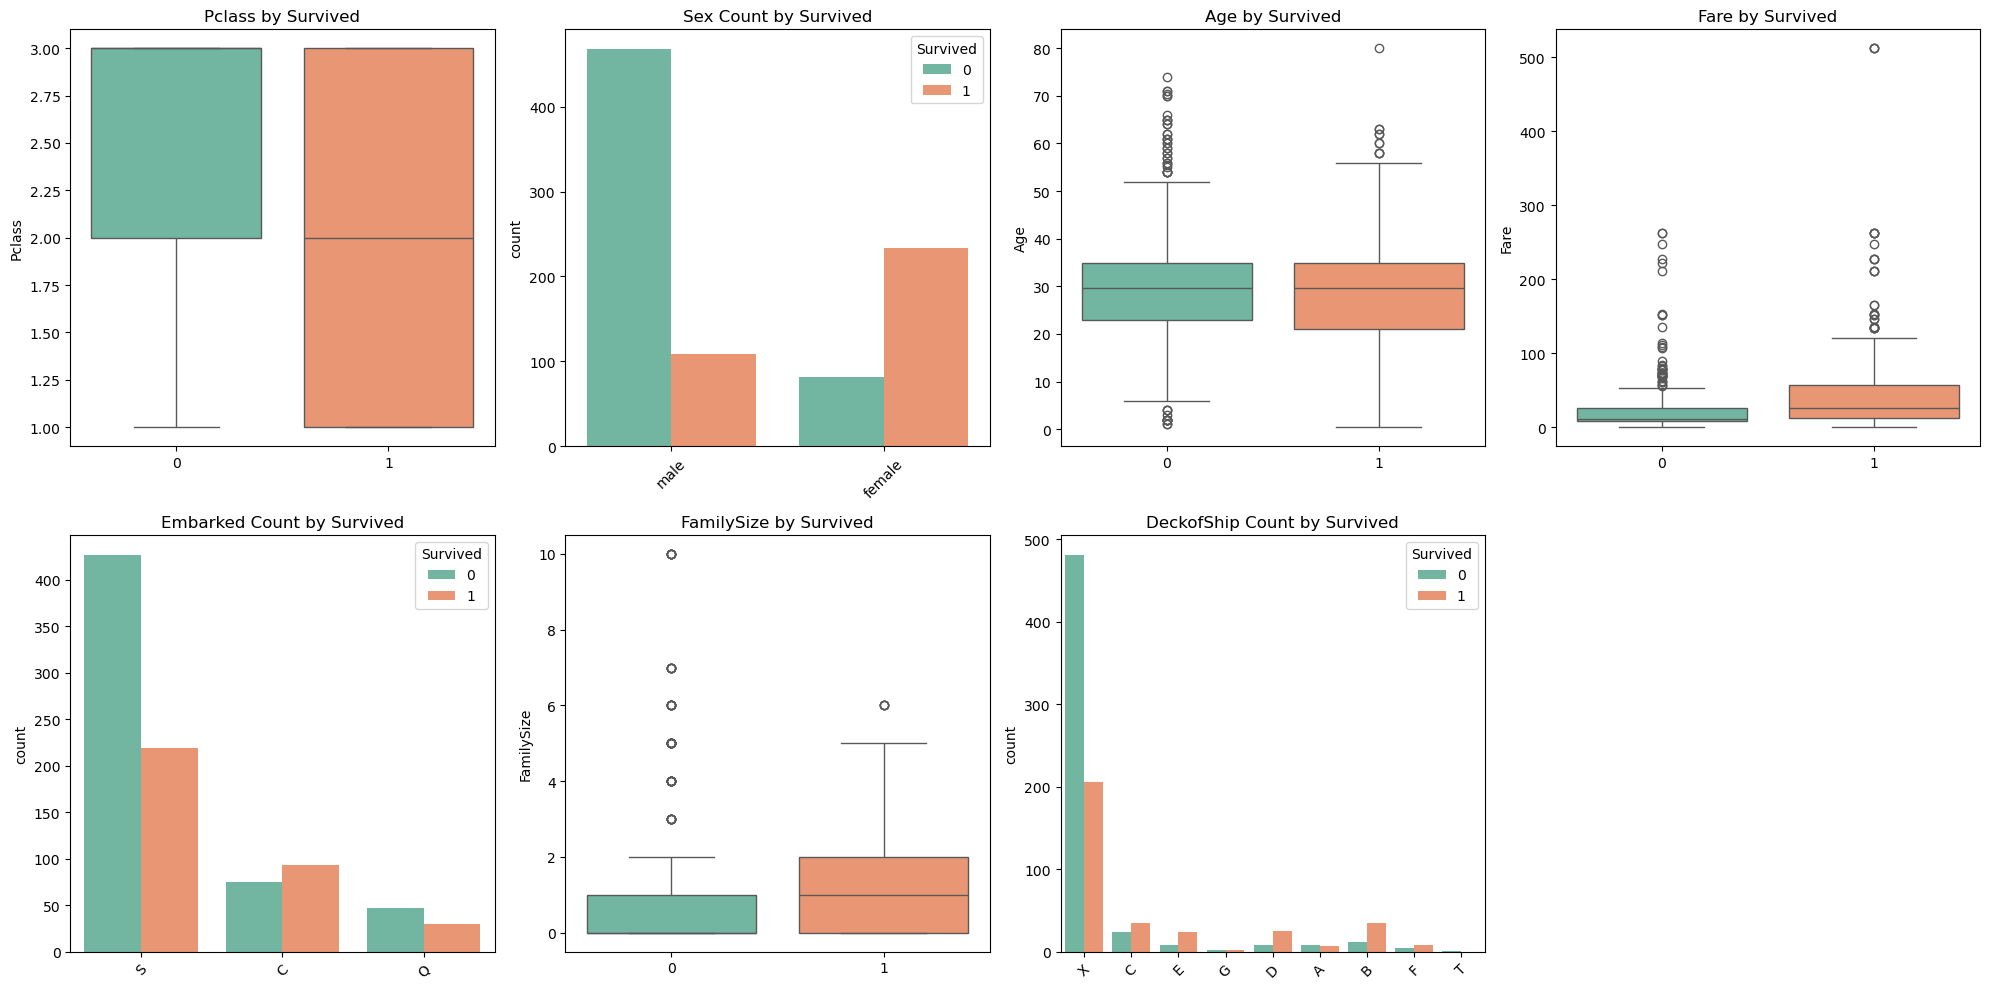

,Feature,Mutual_Info,Pearson_Corr_Abs,VIF_Score
0,Sex,0.158513,0.543351,1.088167
1,Fare,0.138495,0.257307,1.698888
2,FamilySize,0.064403,0.016639,1.213134
3,Pclass,0.060407,0.338481,2.667382
4,DeckofShip,0.040888,0.301116,2.374223
5,Age,0.004211,0.069811,1.206061
6,Embarked,0.000000,0.167675,1.086296


In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

def analyze_features(df, feature_cols, target_col, is_classification=True):
    """
    개선된 피처 분석 함수:
    - 수치형 피처 중심의 VIF 및 Mutual Information(상호 정보량) 기반 통합 분석 리포트 제공
    """
    df_analyzed = df.copy()
    
    # 1. 타겟 변수 안전 인코딩
    if is_classification and (df_analyzed[target_col].dtype in ['object', 'string', 'category']):
        le = LabelEncoder()
        df_analyzed[target_col] = le.fit_transform(df_analyzed[target_col].astype(str))
        
    # [추가 조치] 범주형(문자열) 피처들을 숫자로 안전하게 인코딩 (MI 계산용)
    for col in feature_cols:
        if df_analyzed[col].dtype in ['object', 'string', 'category']:
            le_feat = LabelEncoder()
            df_analyzed[col] = le_feat.fit_transform(df_analyzed[col].astype(str))

    # 2. 수치형 피처만 구분하여 추출 (VIF 및 상관분석용)
    # 위에서 인코딩을 거쳤으므로 이제 모든 피처가 수치형으로 분류됩니다.
    numeric_features = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_analyzed[col])]
    
    if len(numeric_features) < len(feature_cols):
        ignored = set(feature_cols) - set(numeric_features)
        print(f"[주의] 수치형이 아닌 피처 {list(ignored)}는 VIF/상관관계 분석에서 제외되었습니다.")
        
    X_num = df_analyzed[numeric_features].copy()
    X_num = X_num.fillna(X_num.median())  # EDA용 결측치 임시 처리
    y = df_analyzed[target_col].fillna(df_analyzed[target_col].mode()[0])
    
    # 3. Mutual Information (비선형 포함 전체적인 의존도 측정)
    if is_classification:
        mi_scores = mutual_info_classif(X_num, y, random_state=42)
    else:
        mi_scores = mutual_info_regression(X_num, y, random_state=42)
        
    # 4. VIF 계산 (상수항 추가)
    X_vif = X_num.copy()
    X_vif['intercept'] = 1.0
    vif_list = []
    for i in range(X_num.shape[1]):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
            vif_list.append(vif)
        except Exception:
            vif_list.append(np.nan)
            
    # 5. 리포트 생성
    report_df = pd.DataFrame({
        'Feature': numeric_features,
        'Mutual_Info': mi_scores,
        'Pearson_Corr_Abs': X_num.corrwith(y).abs().values,
        'VIF_Score': vif_list
    }).sort_values(by='Mutual_Info', ascending=False).reset_index(drop=True)
    
    print("\n" + "="*60)
    print(" [변수 분석 리포트] ")
    print("="*60)
    print(report_df.round(4))
    print("="*60)
    print("* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심하세요.\n")
    
    # 7. 분포 시각화
    print("\n[시각화] 변수별 시각화를 출력.")
    num_features = len(feature_cols)
    cols_per_row = 4
    rows = (num_features + cols_per_row - 1) // cols_per_row
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(5 * cols_per_row, 5 * rows))
    
    # 행이 여러 개일 때와 1개일 때를 모두 대응하기 위한 플래튼 처리
    if rows == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, col in enumerate(feature_cols):
        # 시각화는 인코딩 전 원본 데이터(df)를 사용해 가독성을 높입니다.
        #sns.boxplot(data=df, x=target_col, y=pd.to_numeric(df[col], errors='coerce'), ax=axes[i], hue=target_col, palette='Set2', legend=False)
        # 1. 원본 데이터프레임에서 x(타겟)와 y(피처) 컬럼만 추출하여 결측치가 없는 데이터만 필터링합니다.
        plot_df = df[[target_col, col]].dropna().copy()
        
        # 2. 만약 해당 피처가 숫자가 아닌 범주형(문자열 등) 데이터라면, boxplot 대신 countplot을 그립니다.
        # 범주형 데이터는 boxplot(상자그림)을 그릴 수 없기 때문입니다.
        if plot_df[col].dtype in ['object', 'string', 'category']:
            sns.countplot(data=plot_df, x=col, hue=target_col, ax=axes[i], palette='Set2')
            axes[i].set_title(f'{col} Count by {target_col}')
            axes[i].tick_params(axis='x', rotation=45) # 글자가 겹치지 않게 회전
        else:
            # 3. 수치형 데이터인 경우에만 안전하게 boxplot을 호출합니다.
            # 데이터가 비어있지 않은지 검증 후 그립니다.
            if not plot_df.empty:
                sns.boxplot(data=plot_df, x=target_col, y=col, ax=axes[i], palette='Set2', hue=target_col, legend=False)
                axes[i].set_title(f'{col} by {target_col}')
        
        axes[i].set_xlabel('')
        
    # 데이터가 채워지지 않은 빈 그래프 서브플롯은 삭제합니다.
    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()
    
    return report_df

# ==========================================
# 데이터 호출 및 실행 부분
# ==========================================
target_ = 'Survived'
feature_ = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'DeckofShip']

# 주의: data_df는 사용자의 타이타닉 데이터프레임 변수명이어야 합니다.
# 함수 호출 시 문자열 따옴표('')를 제거하고 변수명을 그대로 전달해야 합니다.
analyze_features(df=data_df, feature_cols=feature_, target_col=target_)


## 3. 스케일링 (인코딩) 
### 순서가 의미 없는 범주형 컬럼을 원-핫 인코딩 처리
- Sex 
- Embarked 
- DeckofShip

### 수치형 
'Pclass','Age','Fare','FamilySize'

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

#컬럼 구분
category_cols = ['Sex', 'Embarked', 'DeckofShip']
numeric_cols = ['Pclass','Age','Fare','FamilySize']

# 파이프라인 정의
numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
categoric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

# ColumnTransformer로 통합
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categoric_transformer, category_cols),
    ]
    remainder='passthrough' #정의되지 않은 컬럼은 그대로 유지
)

Data_transformed = preprocessor.fit_transform(data_df)

,PassengerId,Survived,Pclass,Name,Sex,Age,Fare,Embarked,FamilySize,DeckofShip
0,1,0,3,"Braund, Owen Harris",male,22.0,7.2500,S,1,X
1,2,1,1,"Cumings, John Bradley (Florence Briggs Thayer)",female,38.0,71.2833,C,1,C
2,3,1,3,"Heikkinen, Laina",female,26.0,7.9250,S,0,X
3,4,1,1,"Futrelle, Jacques Heath (Lily May Peel)",female,35.0,53.1000,S,1,C
4,5,0,3,"Allen, William Henry",male,35.0,8.0500,S,0,X
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,13.0000,S,0,X
887,888,1,1,"Graham, Margaret Edith",female,19.0,30.0000,S,0,B
888,889,0,3,"Johnston, Catherine Helen ""Carrie""",female,29.7,23.4500,S,3,X
889,890,1,1,"Behr, Karl Howell",male,26.0,30.0000,C,0,C


In [137]:
df.isnull().sum()


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
FamilySize       0
DeckofShip       0
dtype: int64